# Predicción de Coste de Seguro Médico

En este cuaderno se desarrolla un análisis exploratorio del dataset de seguros médicos y se construye un modelo de regresión lineal para predecir la variable `charges`.

### Paso 1: Carga del conjunto de datos

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

project_dir = Path.cwd().resolve()
if not (project_dir / "data").exists() and (project_dir.parent / "data").exists():
    project_dir = project_dir.parent

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Cargamos el dataset que ya hemos guardado en la carpeta data/raw
dataset_path = raw_dir / "medical_insurance_cost.csv"
total_data = pd.read_csv(dataset_path)
total_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,"16,884.92"
1,18,male,33.77,1,no,southeast,"1,725.55"
2,28,male,33.00,3,no,southeast,"4,449.46"
3,33,male,22.70,0,no,northwest,"21,984.47"
4,32,male,28.88,0,no,northwest,"3,866.86"


### Paso 2: EDA del dataset

En esta parte revisamos la estructura del dataset, comprobamos si hay valores faltantes o duplicados y observamos qué variables parecen tener más relación con el coste del seguro. La idea es justificar después la selección final de variables.

In [3]:
# Revisamos el tamaño del dataset y una vista general de sus columnas
print(f"Filas y columnas: {total_data.shape}")
display(total_data.info())
display(total_data.describe(include="all").T)

Filas y columnas: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"1,338.00",NaN,NaN,NaN,39.21,14.05,18.00,27.00,39.00,51.00,64.00
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,338.00",NaN,NaN,NaN,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,"1,338.00",NaN,NaN,NaN,1.09,1.21,0.00,0.00,1.00,2.00,5.00
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,"1,338.00",NaN,NaN,NaN,"13,270.42","12,110.01","1,121.87","4,740.29","9,382.03","16,639.91","63,770.43"


In [4]:
# Comprobamos si existen nulos o duplicados
display(total_data.isna().sum().to_frame(name="null_count"))
print(f"Duplicados exactos: {total_data.duplicated().sum()}")

,null_count
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Duplicados exactos: 1


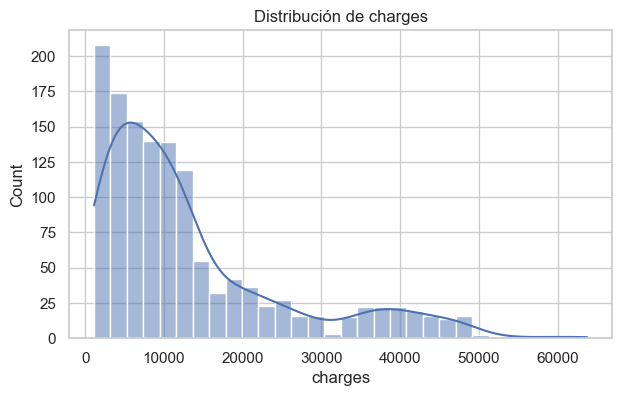

count    1,338.00
mean    13,270.42
std     12,110.01
min      1,121.87
25%      4,740.29
50%      9,382.03
75%     16,639.91
max     63,770.43
Name: charges, dtype: float64

In [5]:
# Vemos la distribución de la variable objetivo
plt.figure(figsize=(7, 4))
sns.histplot(total_data["charges"], kde=True)
plt.title("Distribución de charges")
plt.show()

total_data["charges"].describe()

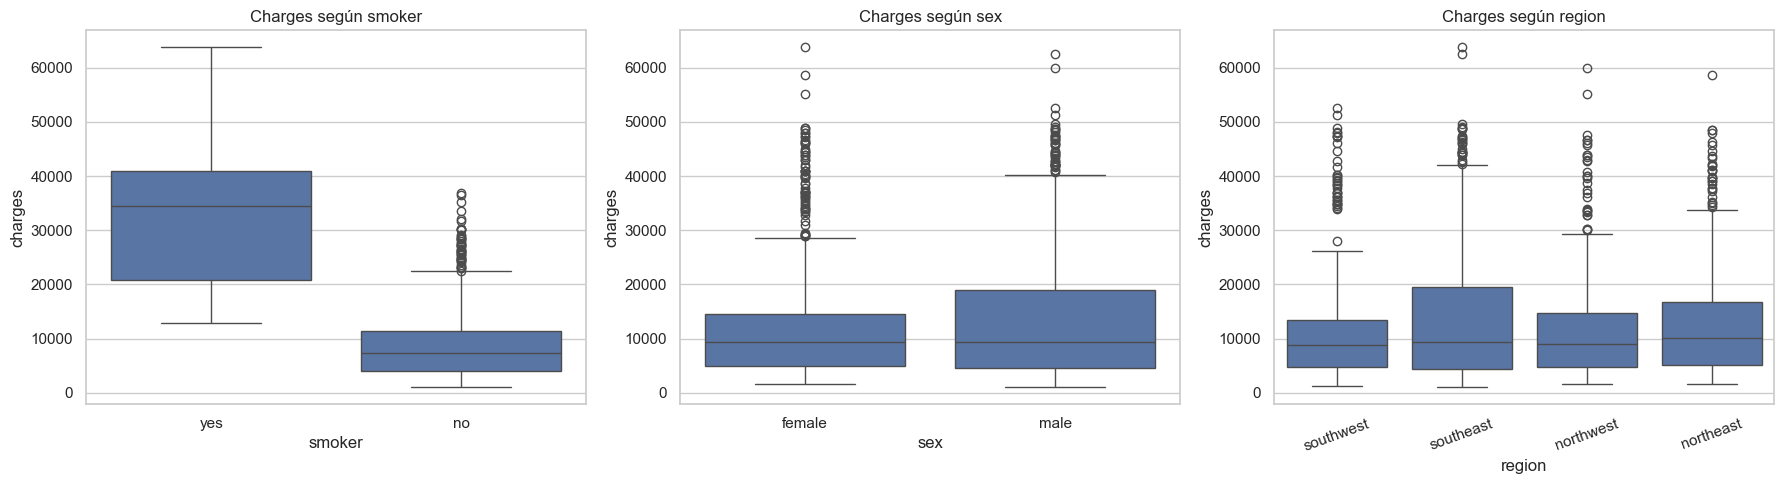

,mean_charges
smoker,
no,"8,434.27"
yes,"32,050.23"


,mean_charges
sex,
female,"12,569.58"
male,"13,956.75"


,mean_charges
region,
southeast,"14,735.41"
northeast,"13,406.38"
northwest,"12,417.58"
southwest,"12,346.94"


In [6]:
# Comparamos charges con algunas variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=total_data, x="smoker", y="charges", ax=axes[0])
axes[0].set_title("Charges según smoker")

sns.boxplot(data=total_data, x="sex", y="charges", ax=axes[1])
axes[1].set_title("Charges según sex")

sns.boxplot(data=total_data, x="region", y="charges", ax=axes[2])
axes[2].set_title("Charges según region")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(total_data.groupby("smoker")["charges"].mean().to_frame("mean_charges"))
display(total_data.groupby("sex")["charges"].mean().to_frame("mean_charges"))
display(total_data.groupby("region")["charges"].mean().to_frame("mean_charges").sort_values(by="mean_charges", ascending=False))

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


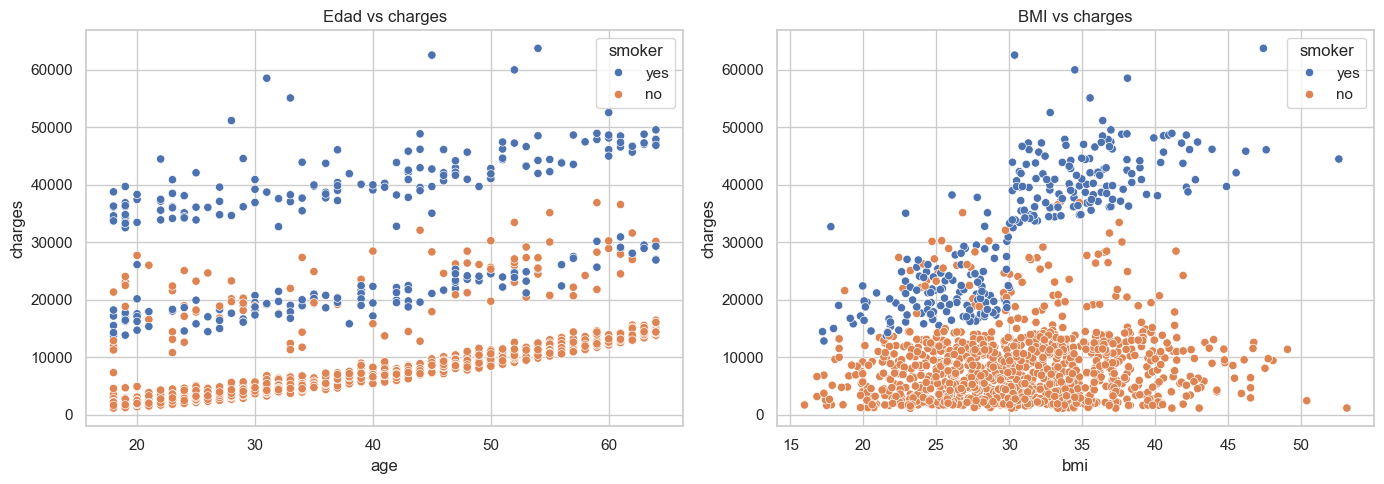

In [7]:
# Observamos relaciones entre variables numéricas y el coste
numeric_columns = ["age", "bmi", "children", "charges"]
display(total_data[numeric_columns].corr())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=total_data, x="age", y="charges", hue="smoker", ax=axes[0])
axes[0].set_title("Edad vs charges")

sns.scatterplot(data=total_data, x="bmi", y="charges", hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs charges")

plt.tight_layout()
plt.show()

### Selección de variables

Después del EDA, las variables que más sentido tienen para el modelo son `age`, `bmi`, `children` y `smoker`. Las columnas `sex` y `region` muestran diferencias menores y por eso se dejan fuera del modelado principal.

In [8]:
# Nos quedamos solo con las variables que vamos a usar en el modelo
selected_features = ["age", "bmi", "children", "smoker", "charges"]
model_data = total_data[selected_features].copy()

processed_path = processed_dir / "medical_insurance_selected.csv"
model_data.to_csv(processed_path, index=False)
print(f"Dataset reducido guardado en: {processed_path}")
model_data.head()

Dataset reducido guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Proyecto-de-Regresi-n-Lineal-main/data/processed/medical_insurance_selected.csv


,age,bmi,children,smoker,charges
0,19,27.90,0,yes,"16,884.92"
1,18,33.77,1,no,"1,725.55"
2,28,33.00,3,no,"4,449.46"
3,33,22.70,0,no,"21,984.47"
4,32,28.88,0,no,"3,866.86"


### Preparación para el modelo

In [9]:
# Separamos variables predictoras y variable objetivo
X = model_data.drop(columns=["charges"])
y = model_data["charges"]

# Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 4)
X_test shape: (268, 4)
y_train shape: (1070,)
y_test shape: (268,)


In [10]:
# Guardamos train y test para dejar trazabilidad del proceso
train_data = X_train.copy()
train_data["charges"] = y_train.values
test_data = X_test.copy()
test_data["charges"] = y_test.values

train_path = processed_dir / "medical_insurance_train.csv"
test_path = processed_dir / "medical_insurance_test.csv"
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

print(f"Train guardado en: {train_path}")
print(f"Test guardado en: {test_path}")

Train guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Proyecto-de-Regresi-n-Lineal-main/data/processed/medical_insurance_train.csv
Test guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Proyecto-de-Regresi-n-Lineal-main/data/processed/medical_insurance_test.csv


In [11]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return {
        "model": name,
        "r2": round(r2_score(y_test, predictions), 4),
        "rmse": round(mean_squared_error(y_test, predictions) ** 0.5, 4),
        "mae": round(mean_absolute_error(y_test, predictions), 4),
    }


categorical_features = ["smoker"]
numeric_features = ["age", "bmi", "children"]

### Paso 3: Modelo de regresión lineal base

Primero entrenamos una regresión lineal simple con los hiperparámetros por defecto para tener una referencia clara del rendimiento inicial.

In [12]:
# Pipeline base con escalado en numéricas y codificación para smoker
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_features),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        ("model", LinearRegression()),
    ]
)

baseline_results = evaluate_model(
    "linear_regression_base", baseline_model, X_train, X_test, y_train, y_test
)

pd.DataFrame([baseline_results])

,model,r2,rmse,mae
0,linear_regression_base,0.78,"5,829.38","4,213.80"


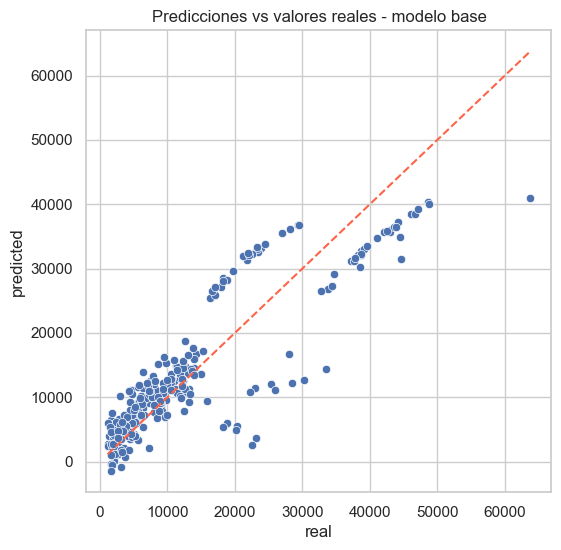

In [13]:
# Revisamos visualmente las predicciones del modelo base
baseline_predictions = baseline_model.predict(X_test)
baseline_plot = pd.DataFrame({
    "real": y_test.values,
    "predicted": baseline_predictions,
})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=baseline_plot, x="real", y="predicted")
plt.plot(
    [baseline_plot["real"].min(), baseline_plot["real"].max()],
    [baseline_plot["real"].min(), baseline_plot["real"].max()],
    color="tomato",
    linestyle="--",
)
plt.title("Predicciones vs valores reales - modelo base")
plt.show()

### Paso 4: Optimización del modelo

Como el rendimiento del modelo base todavía puede mejorar, probamos una versión con `Ridge` y expansión polinómica para capturar relaciones no lineales entre las variables.

In [14]:
# Para la versión optimizada convertimos smoker a binaria
X_optimized = X.copy()
X_optimized["smoker_numeric"] = (X_optimized["smoker"] == "yes").astype(int)
X_optimized = X_optimized.drop(columns=["smoker"])

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_optimized,
    y,
    test_size=0.2,
    random_state=42
)

optimized_pipeline = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]
)

param_grid = {
    "poly__degree": [1, 2, 3],
    "model__alpha": [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=optimized_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

optimized_results = evaluate_model(
    "ridge_optimized", grid_search, X_train_opt, X_test_opt, y_train_opt, y_test_opt
)

comparison = pd.DataFrame([baseline_results, optimized_results]).sort_values(by="r2", ascending=False)
comparison

,model,r2,rmse,mae
1,ridge_optimized,0.87,"4,486.60","2,722.61"
0,linear_regression_base,0.78,"5,829.38","4,213.80"


In [15]:
# Guardamos la comparación y mostramos los mejores hiperparámetros
comparison_path = processed_dir / "medical_insurance_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"Comparación guardada en: {comparison_path}")
print("Mejores hiperparámetros:", grid_search.best_params_)
comparison

Comparación guardada en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Proyecto-de-Regresi-n-Lineal-main/data/processed/medical_insurance_model_comparison.csv
Mejores hiperparámetros: {'model__alpha': 0.1, 'poly__degree': 3}


,model,r2,rmse,mae
1,ridge_optimized,0.87,"4,486.60","2,722.61"
0,linear_regression_base,0.78,"5,829.38","4,213.80"


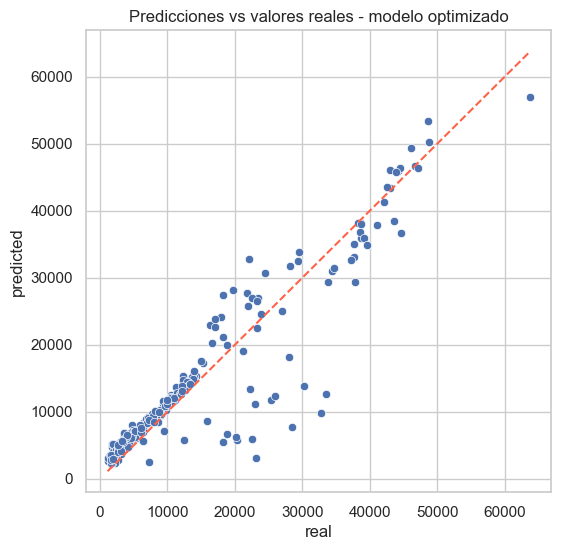

,real,predicted
0,"9,095.07","9,489.88"
1,"5,272.18","6,260.24"
2,"29,330.98","32,450.47"
3,"9,301.89","9,942.12"
4,"33,750.29","29,338.31"


In [16]:
# Revisamos el ajuste del mejor modelo
best_model = grid_search.best_estimator_
optimized_predictions = best_model.predict(X_test_opt)

optimized_plot = pd.DataFrame({
    "real": y_test_opt.values,
    "predicted": optimized_predictions,
})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=optimized_plot, x="real", y="predicted")
plt.plot(
    [optimized_plot["real"].min(), optimized_plot["real"].max()],
    [optimized_plot["real"].min(), optimized_plot["real"].max()],
    color="tomato",
    linestyle="--",
)
plt.title("Predicciones vs valores reales - modelo optimizado")
plt.show()

optimized_plot.head()

### Conclusiones

- El dataset está limpio y no presenta valores nulos ni duplicados importantes.
- Las variables más útiles para este problema son `age`, `bmi`, `children` y `smoker`.
- El modelo base de regresión lineal ofrece una referencia razonable, pero la versión optimizada mejora las métricas.
- Fumar sigue siendo la característica que más influye en el coste del seguro médico.